# Notebook for plotting additional canonical evolution Figure A2
## Preamble
### Load packages required

In [2]:
#SJL 6/2020
#Script to plot the change in surface length for planets in the canonical model


###########################################################
###########################################################
###########################################################
import numpy as np
import scipy as sp
import sys
import os
import struct
from scipy import constants as const

import scipy.integrate as integrate
from scipy.optimize import curve_fit

#package to use wildcards 
import fnmatch

from scipy.interpolate import LinearNDInterpolator
#from matplotlib.mlab import griddata
from scipy.interpolate import griddata

#plotting packages
import matplotlib as mpl
#mpl.use('PDF')
import matplotlib.pyplot as plt
import pylab
import matplotlib.cm as cm
from matplotlib import gridspec

cwd = os.getcwd()
print(cwd)
if sys.platform== 'darwin':
    sys.path.insert(0, cwd+'/Support_scipts')
    print(cwd+'/Support_scripts')
elif (sys.platform== 'win32') | (sys.platform== 'win64'):
    sys.path.insert(0,cwd+"\\Support_scipts")


#HERCULES_structures
from HERCULES_structures import *
from surface_size_calc import *
from HERCULES_random_planet_database_structure_1D import *

#functions for calculating non-evenly spaced numerical differentials
from gradients import *

#import colormaps
import colormaps as cmaps
import matplotlib.cm as cm

import svglib.svglib as svglib
svglib.register_font('helvetica', './Helvetica.ttc')


/Users/vq21447/Documents/Lock_2026_SI
/Users/vq21447/Documents/Lock_2026_SI/Support_scripts
CHECK THE LOCATION OF ODYSSEY BACKUP
CHECK THE LOCATION OF ODYSSEY BACKUP


('helvetica', True)

### Define constants

In [3]:
########################################################################################
########################################################################################
########################################################################################
#CONSTANTS
MEarth=5.972E24
LEM=3.5E34
REarth=6.371E6
MMoon=7.34767309E22

aMoon=0.3844E9
aCassini=30*REarth
aRoche=2.9*REarth

#for HERCULES
MEarth_H=5.9879648E24
LEM_H=3.53E34

### Set parameters and select bodies to plot

In [4]:
########################################################################################
########################################################################################
########################################################################################
#PARAMS
Hdir='Earth_correct_params_S3.20c'
Hname='Earth_correct_params_S3.20c'

#flag as to whether to run in plotting mode or whether to redo calculations
flag_calc=0

#number of contor lines
Ncont=20


## Main script
### Either calculate the rates of shape change or read in the pre-calculated data

In [5]:
########################################################################################
########################################################################################
########################################################################################
#MAIN

########################################################################################
#read in the database

Hdatabase=HERCULES_random_planet_database_1D()
Hdatabase.make_array(Hdir,Hname)
Hdatabase.initialize_interpolation([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1],\
                                   [0,0,[],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]], flag_extrap=1)

#extract the latitudes for each Mu point
Nmu=Hdatabase.parr[0].Nmu
lat=np.arccos(Hdatabase.parr[0].layers[0].mu)*180/np.pi

if flag_calc==1:
    
    Nplot=50
    L=np.linspace(0.18,0.82,Nplot)*LEM
    #L=np.linspace(0.18,2,Nplot)*LEM
    deltaL=1E-5*LEM
    
    #calculate legnths then take gradient
    ddl_lat_dL=np.zeros((Nplot,Nmu))
    ddl_lon_dL=np.zeros((Nplot,Nmu))
    ddA_dL=np.zeros((Nplot,Nmu))
    
    #calculating gradient before interpolation
    ddl_lat_dL_native=np.zeros((Nplot,Nmu))
    ddl_lon_dL_native=np.zeros((Nplot,Nmu))
    ddA_dL_native=np.zeros((Nplot,Nmu))
    
    #temporary arrays
    dl_lat=np.empty((3,Nmu))
    dl_lon=np.empty((3,Nmu))
    dA=np.empty((3,Nmu))
    
    for i in np.arange(Nplot):
        print(i)
        Lcalc=np.asarray([L[i]-deltaL,L[i],L[i]+deltaL])
        
        for k in np.arange(3):
            temp_data=Hdatabase.interp_database(Lcalc[k],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
                                                   [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]],flag_extrap=1)
    
            temp=np.asarray(temp_data[16])
    
            dl_lat[k,:]=temp[:,0]
            dl_lon[k,:]=temp[:,1]
            dA[k,:]=temp[:,2]
            
            if k==1:
                ddl_lat_dL_native[i,:]=temp[:,3]*np.pi/180.0
                ddl_lon_dL_native[i,:]=temp[:,4]*np.pi/180.0
                ddA_dL_native[i,:]=temp[:,5]*(np.pi/180.0)**2
    

    #activate if you want to reprint the run data
    if 1==1:
        np.savez('Data/FigureA2', Nmu=Nmu, lat=lat, L=L,\
                 dl_lat=dl_lat, dl_lon=dl_lon, dA=dA, ddl_lat_dL_native=ddl_lat_dL_native, ddl_lon_dL_native=ddl_lon_dL_native,\
                 ddA_dL_native=ddA_dL_native)
                
                
else:

    temp=np.load("Data/FigureA2.npz")
    Nmu=temp['Nmu']
    lat=temp['lat']
    L=temp['L']
    dl_lat=temp['dl_lat']
    dl_lon=temp['dl_lon']
    dA=temp['dA']
    ddl_lat_dL_native=temp['ddl_lat_dL_native']
    ddl_lon_dL_native=temp['ddl_lon_dL_native']
    ddA_dL_native=temp['ddA_dL_native']

    
            
print('done')

Earth_correct_params_S3.20c
	 Earth_correct_params_S3.20c_AM3.3125
	 Earth_correct_params_S3.20c_AM3.30625
	 Earth_correct_params_S3.20c_AM3.325
done


### Fit power laws to rate of change data at each lat

In [6]:
#############################################################
#now look at how well ddl/dL follow a power law and what is the exponent
#first calculate the fits
def power_law(x,b,c):
    return b*(x**c)

#Take an array of mu points
indmu=np.arange(Hdatabase.parr[0].Nmu)

#initialize fit and variance arrays
lat_fit_mu=np.empty([2,Hdatabase.parr[0].Nmu])
lon_fit_mu=np.empty([2,Hdatabase.parr[0].Nmu])
A_fit_mu=np.empty([2,Hdatabase.parr[0].Nmu])

lat_pcov_mu=np.empty([2,Hdatabase.parr[0].Nmu])
lon_pcov_mu=np.empty([2,Hdatabase.parr[0].Nmu])
A_pcov_mu=np.empty([2,Hdatabase.parr[0].Nmu])

#loop through and fit the power law
for i in indmu:
    
    lat_fit_mu[:,i], pcov = curve_fit(power_law, L/LEM, ddl_lat_dL_native[:,i]*LEM,p0=[1E3,0.9],maxfev = 8000)
    lat_pcov_mu[:,i]=np.diagonal(pcov)
    lon_fit_mu[:,i], pcov = curve_fit(power_law, L/LEM, ddl_lon_dL_native[:,i]*LEM,p0=[1E4,0.9],maxfev = 8000)
    lon_pcov_mu[:,i]=np.diagonal(pcov)
    A_fit_mu[:,i], pcov = curve_fit(power_law, L/LEM, ddA_dL_native[:,i]*LEM,p0=[1E8,0.9],maxfev = 8000)
    A_pcov_mu[:,i]=np.diagonal(pcov)

### Construct Figure A2

[0.]
[30.03311837]
[39.98915815]
[59.86727817]


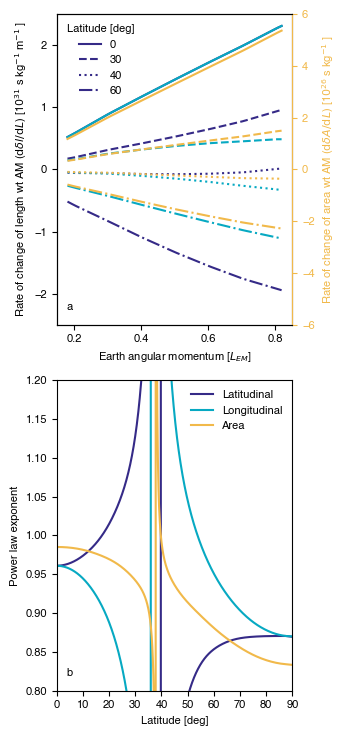

In [96]:
#create a dummy figure figure first to avoid plotting issues
fig = plt.figure(figsize=(3.9,6.5))
font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)
gs = gridspec.GridSpec(2, 1, height_ratios=[0.64,1])
ax=plt.subplot(gs[0])
ax1=plt.subplot(gs[1])
fig.tight_layout()
plt.savefig('FigureA2.pdf')
mpl.pyplot.close(fig)

#plot for paper just looking at the power

#initialise the figure
fig = plt.figure(figsize=(3.5,7.4))
gs = gridspec.GridSpec(2, 1)
ax=[[]]
ax[0].append(plt.subplot(gs[0]))
ax[0].append(plt.subplot(gs[1]))

# ax_twiny=ax[0][0].twiny()
ax_twin=ax[0][0].twinx()

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}

mpl.rc('font', **font)

col=cmaps.parula(np.linspace(0,0.8,3))

#plot some example lines
ind_plot=[0,500,642,864]
lines=['-','--',':','-.']
for i in np.arange(np.size(ind_plot)):
    print(90-lat[[ind_plot[i]]])

    ax[0][0].plot(L/LEM,ddl_lat_dL_native[:,ind_plot[i]]*1E31,lines[i],color=col[0],\
                  label=str(round((90-lat[[ind_plot[i]]])[0])))
    ax[0][0].plot(L/LEM,ddl_lon_dL_native[:,ind_plot[i]]*1E31,lines[i],color=col[1])
    ax_twin.plot(L/LEM,ddA_dL_native[:,ind_plot[i]]*1E26,lines[i],color=col[2])

ax[0][0].set_xlabel('Earth angular momentum [$L_{EM}$]')
ax[0][0].set_ylabel('Rate of change of length wt AM ($\mathrm{d} \delta l/\mathrm{d} L$) [1$0^{31}$ s kg$^{-1}$ m$^{-1}$ ]')

ax[0][0].set_ylim([-2.5,2.5])
ax_twin.set_ylim([-6,6])

ax_twin.set_ylabel('Rate of change of area wt AM ($\mathrm{d} \delta A/\mathrm{d} L$) [1$0^{26}$ s kg$^{-1}$ ]')
ax_twin.spines['right'].set_color(col[2])
ax_twin.yaxis.label.set_color(col[2])
ax_twin.tick_params(axis='y', colors=col[2])

ax[0][0].legend(frameon=False, title="Latitude [deg]", loc="upper left")

#plot the fits and covariances
ax[0][1].plot(90.0-lat,lat_fit_mu[1,:],'-',color=col[0],label='Latitudinal')
ax[0][1].plot(90.0-lat,lon_fit_mu[1,:],'-',color=col[1],label='Longitudinal')
ax[0][1].plot(90.0-lat,A_fit_mu[1,:],'-',color=col[2],label='Area')

ax[0][1].set_ylim([0.8,1.2])
ax[0][1].set_xlim([0,90])
ax[0][1].set_xticks(np.arange(0,10)*10)


ax[0][1].set_xlabel('Latitude [deg]')
ax[0][1].set_ylabel('Power law exponent')

ax[0][1].legend(frameon=False)

ax[0][0].text(0.04, 0.04, 'a', \
                       horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][0].transAxes, color='k')
ax[0][1].text(0.04, 0.04, 'b', \
                       horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][1].transAxes, color='k')


fig.tight_layout()

plt.savefig('FigureA2.pdf')

